# Vv-Gamma チャート作成例

`VVGammaChart.py` の薄い使用例です。主計算はモジュール側に置き、notebook は条件設定・実行・可視化だけにします。

In [1]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import sys
import os

# ../bin/AnalysisVSPAERO.py をモジュールとしてインポート
sys.path.append(os.path.join('../../../')) # 親ディレクトリをモジュール探索パスに追加
from src.VvGammaChart import (
    calculate_stab_basic_metrics,
    plot_vv_gamma_contour,
    postprocess_vv_gamma_cases,
    run_vv_wtip_stability_sweep,
)

## 1. 既存 `.stab` の読み取り確認

OpenVSP が使えない環境でも、`.stab` の後処理だけは確認できます。

In [2]:
metrics = calculate_stab_basic_metrics(
    '../../models/BRGlider/BRGlider.stab',
    vv=np.nan,
    tip_deflection=np.nan,
)
pd.Series(metrics)[[
    'Gamma_eff_deg',
    'CL_alpha',
    'Cl_beta',
    'Cn_beta',
    'Cl_delta_r',
    'Cn_delta_r',
    'spiral_margin',
    'control_column_delta_r',
]]

Gamma_eff_deg             5.287216
CL_alpha                  5.983843
Cl_beta                  -0.117177
Cn_beta                  -0.003417
Cl_delta_r                0.002638
Cn_delta_r               -0.007557
spiral_margin             0.001936
control_column_delta_r    ConGrp_3
dtype: object

## 2. Vv-wtip stability sweep の条件

以下は OpenVSP Python API が使える環境で実行します。ここでは `.vsp3` 生成と VSPAERO 安定微係数解析までを行い、旋回指標などの後処理は次のステップで行います。

In [3]:
base_vsp3_path = Path('../../models/BRGlider/BRGlider.0G.vsp3')
output_dir = Path('')

vv_values = np.linspace(0.001, 0.006, 11)
tip_deflections = np.linspace(0.0, 2.0, 11)

flight_condition = {
    'alpha_deg': 0.0,
    'mach': 0.0,
    'reynolds': 1.0e6,
}

geometry_config = {
    'lv': 4.5,          # x_ac_vtail - xcg, model length unit
    'wing_area': 18,
    'wing_span': 27,
    'xcg': 1.4,
    'wing_name': 'WingGeom',
    'vtail_name': 'VTailGeom',
    'n_span': 101,
    "vtail_area_scale_mode": "fixed_aspect_ratio",
}

In [4]:
print(vv_values)
print(tip_deflections)

[0.001  0.0015 0.002  0.0025 0.003  0.0035 0.004  0.0045 0.005  0.0055
 0.006 ]
[0.  0.2 0.4 0.6 0.8 1.  1.2 1.4 1.6 1.8 2. ]


In [5]:
sweep = run_vv_wtip_stability_sweep(
    base_vsp3_path,
    vv_values,
    tip_deflections,
    flight_condition,
    geometry_config,
    output_dir,
    validate_base_model=True,
    fixed_wake_flag=False,
    wake_num_iter=10,
    ncpu=8,
    verbose=1,
)
sweep.head()


-> Validate G103A stability-derivative preflight: C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP\examples\models\BRGlider\BRGlider.0G.vsp3
 Checking required Geoms...
 Checking required control-surface Subsurfaces...
 Checking ThickGeom / ThinGeom sets...
 Checking VSPAERO settings...
 Checking VSPAERO control-surface groups and gains...
 Validation PASSED: 0 error(s), 0 warning(s)

-> Calculate G103A VSPAERO stability derivatives: C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP\examples\notebooks\vv_gamma_chart\vv_0p00100_wtip_0p00000\vv_0p00100_wtip_0p00000.vsp3
 Executing VSPAEROComputeGeometry...
Executing VSPAEROSweep with STABILITY_DEFAULT
 Stability derivative calculation PASSED: 0 error(s), 0 warning(s)

-> Calculate G103A VSPAERO stability derivatives: C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP\examples\notebooks\vv_gamma_chart\vv_0p00100_wtip_0p20000\vv_0p00100_wtip_0p20000.vsp3
 Executing VSPAEROComputeGeometry...
Executing VSPAEROSweep with STABILITY_DEFAULT
 Stability 

,case,case_index,case_count,Vv,tip_deflection,case_dir,vsp3_path,stab_path,passed,vspaero_passed,...,wing_dihedral_update_count,vspaero_wall_elapsed_s,vspaero_read_vsp3_elapsed_s,vspaero_compute_geometry_elapsed_s,vspaero_compute_geometry_analysis_duration_s,vspaero_vspaero_sweep_elapsed_s,vspaero_vspaero_sweep_analysis_duration_s,vspaero_result_extraction_elapsed_s,vspaero_total_elapsed_s,elapsed_s
0,vv_0p00100_wtip_0p00000,1,121,0.001,0.0,vv_0p00100_wtip_0p00000,vv_0p00100_wtip_0p00000\vv_0p00100_wtip_0p0000...,vv_0p00100_wtip_0p00000\vv_0p00100_wtip_0p0000...,True,True,...,4,225.913913,0.153659,0.297873,0.298,225.458749,225.459,0.000880,225.913072,226.324220
1,vv_0p00100_wtip_0p20000,2,121,0.001,0.2,vv_0p00100_wtip_0p20000,vv_0p00100_wtip_0p20000\vv_0p00100_wtip_0p2000...,vv_0p00100_wtip_0p20000\vv_0p00100_wtip_0p2000...,True,True,...,4,224.249379,0.172813,0.278878,0.278,223.793797,223.794,0.000887,224.248409,224.729078
2,vv_0p00100_wtip_0p40000,3,121,0.001,0.4,vv_0p00100_wtip_0p40000,vv_0p00100_wtip_0p40000\vv_0p00100_wtip_0p4000...,vv_0p00100_wtip_0p40000\vv_0p00100_wtip_0p4000...,True,True,...,4,206.783873,0.155115,0.274119,0.274,206.350667,206.350,0.000877,206.782941,207.278098
3,vv_0p00100_wtip_0p60000,4,121,0.001,0.6,vv_0p00100_wtip_0p60000,vv_0p00100_wtip_0p60000\vv_0p00100_wtip_0p6000...,vv_0p00100_wtip_0p60000\vv_0p00100_wtip_0p6000...,True,True,...,4,212.898945,0.173197,0.589133,0.589,212.132687,212.133,0.000901,212.898129,213.382606
4,vv_0p00100_wtip_0p80000,5,121,0.001,0.8,vv_0p00100_wtip_0p80000,vv_0p00100_wtip_0p80000\vv_0p00100_wtip_0p8000...,vv_0p00100_wtip_0p80000\vv_0p00100_wtip_0p8000...,True,True,...,4,214.856385,0.163861,0.287416,0.287,214.401457,214.401,0.000833,214.855531,215.338259


## 3. 後処理

既存の `.stab` 群から、`Gamma_eff`、準静的ロールラダーゲイン、6DOFロール応答、旋回トリム指標を計算します。`mass` と `inertia` は対象機の値に置き換えてください。

In [6]:
# TODO: 対象機の質量・慣性モーメントに置き換えてください。
# 以下の値は notebook の呼び出し形を示すための仮置きです。
mass = 100.0
inertia = {
    'Ixx': 1000.0,
    'Iyy': 75.0,
    'Izz': 1000.0,
    'Ixz': 0.0,
}

results = postprocess_vv_gamma_cases(
    sweep,
    mass=mass,
    inertia=inertia,
    delta_r=math.radians(10.0),
    target_delta_phi=math.radians(5.0),
    turn_trim_mode='gliding',
    turn_trim_phi=math.radians(5.0),
    output_csv_path=output_dir / 'vv_gamma_metrics.csv',
    history_output_dir=output_dir / '6dof_history',
    write_6dof_history=False,
    plot_6dof_history=False,
    verbose=1,
)
results.head()

[2026-07-05 18:35:42] Postprocess case failed: vv_0p00100_wtip_0p00000: ModuleNotFoundError("No module named 'TurnTrimSolver'")
[2026-07-05 18:35:42] Postprocess case failed: vv_0p00100_wtip_0p20000: ModuleNotFoundError("No module named 'TurnTrimSolver'")
[2026-07-05 18:35:42] Postprocess case failed: vv_0p00100_wtip_0p40000: ModuleNotFoundError("No module named 'TurnTrimSolver'")
[2026-07-05 18:35:42] Postprocess case failed: vv_0p00100_wtip_0p60000: ModuleNotFoundError("No module named 'TurnTrimSolver'")
[2026-07-05 18:35:42] Postprocess case failed: vv_0p00100_wtip_0p80000: ModuleNotFoundError("No module named 'TurnTrimSolver'")
[2026-07-05 18:35:42] Postprocess case failed: vv_0p00100_wtip_1p00000: ModuleNotFoundError("No module named 'TurnTrimSolver'")
[2026-07-05 18:35:42] Postprocess case failed: vv_0p00100_wtip_1p20000: ModuleNotFoundError("No module named 'TurnTrimSolver'")
[2026-07-05 18:35:42] Postprocess case failed: vv_0p00100_wtip_1p40000: ModuleNotFoundError("No module n

,case,case_index,case_count,Vv,tip_deflection,case_dir,vsp3_path,stab_path,passed,vspaero_passed,...,Bref,Cref,Xcg,Ycg,Zcg,AoA_deg,Beta_deg,Mach,Rho,Vinf
0,vv_0p00100_wtip_0p00000,1,121,0.001,0.0,vv_0p00100_wtip_0p00000,vv_0p00100_wtip_0p00000\vv_0p00100_wtip_0p0000...,vv_0p00100_wtip_0p00000\vv_0p00100_wtip_0p0000...,True,True,...,27.0,0.625,1.4,0.0,0.0,0.0,0.0,0.0,1.225,10.0
1,vv_0p00100_wtip_0p20000,2,121,0.001,0.2,vv_0p00100_wtip_0p20000,vv_0p00100_wtip_0p20000\vv_0p00100_wtip_0p2000...,vv_0p00100_wtip_0p20000\vv_0p00100_wtip_0p2000...,True,True,...,27.0,0.625,1.4,0.0,0.0,0.0,0.0,0.0,1.225,10.0
2,vv_0p00100_wtip_0p40000,3,121,0.001,0.4,vv_0p00100_wtip_0p40000,vv_0p00100_wtip_0p40000\vv_0p00100_wtip_0p4000...,vv_0p00100_wtip_0p40000\vv_0p00100_wtip_0p4000...,True,True,...,27.0,0.625,1.4,0.0,0.0,0.0,0.0,0.0,1.225,10.0
3,vv_0p00100_wtip_0p60000,4,121,0.001,0.6,vv_0p00100_wtip_0p60000,vv_0p00100_wtip_0p60000\vv_0p00100_wtip_0p6000...,vv_0p00100_wtip_0p60000\vv_0p00100_wtip_0p6000...,True,True,...,27.0,0.625,1.4,0.0,0.0,0.0,0.0,0.0,1.225,10.0
4,vv_0p00100_wtip_0p80000,5,121,0.001,0.8,vv_0p00100_wtip_0p80000,vv_0p00100_wtip_0p80000\vv_0p00100_wtip_0p8000...,vv_0p00100_wtip_0p80000\vv_0p00100_wtip_0p8000...,True,True,...,27.0,0.625,1.4,0.0,0.0,0.0,0.0,0.0,1.225,10.0


## 4. 可視化

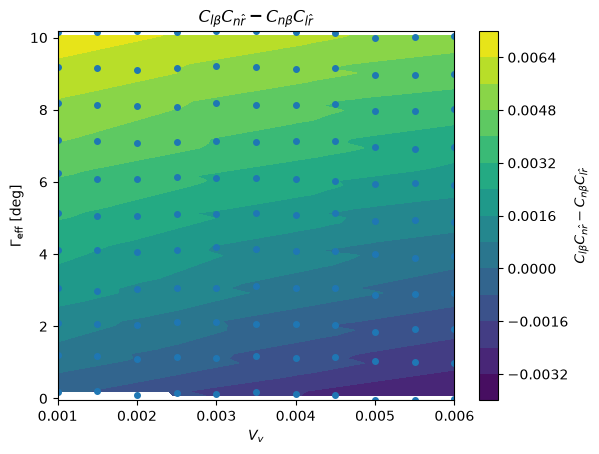

KeyError: "results is missing required column(s): ['sixdof_roll_response_metric']"

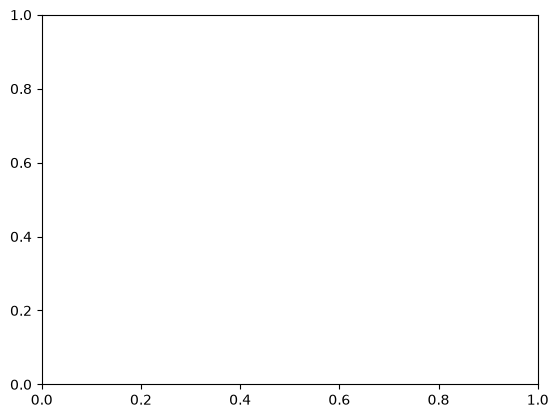

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
plot_vv_gamma_contour(results, 'spiral_margin', ax=ax)
plt.show()

fig, ax = plt.subplots()
plot_vv_gamma_contour(results, 'sixdof_roll_response_metric', ax=ax)
plt.show()

fig, ax = plt.subplots()
plot_vv_gamma_contour(results, 'turn_trim_delta_r', ax=ax)
plt.show()